In [8]:
from matplotlib.gridspec import GridSpec
import networkx as nx
from itertools import product
from collections import defaultdict
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import circmean
from scipy.stats import circstd
from pathlib import Path
import sys
import numpy as np
import glob
import os
from scipy.stats import iqr
from scipy.ndimage import gaussian_filter
import brainpy.checkpoints as bc



%load_ext autoreload
%autoreload

def get_parent_dir():
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path.cwd().parent

parent_dir = str(get_parent_dir())
print("Parent directory:", parent_dir)

sys.path.append(parent_dir)
import models.load_state_patch
from stimulus_experiments.entrainment_experiments import *
from stimulus_experiments.entrainment_analysis import *
from stimulus_experiments.main_entrain import (
    parse_args,
    build_train_config,
    build_baseline_config,
    build_test_config,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Parent directory: c:\Users\HP\ModellingProjects\Olivocerebellar-circuit


In [ ]:
import itertools

def sweep_convergence_params_grid(
    m_thresholds,
    var_thresholds,
    chunk_thresholds,
    epoch_times,
    seed=85,
    simdur=10_000,
    experiment="nostim",
    monitor_preset="plasticity_min",
    downsample=40,
    tag_prefix="conv_sweep",
    parent_dir=None,
):
    results = []

    # Cross product over all threshold dimensions
    for conv_thresh_m, conv_thresh_var, chunk_thresh in itertools.product(
        m_thresholds, var_thresholds, chunk_thresholds
    ):
        # And then over epoch_times
        for epoch_time in epoch_times:
            result_tag = (
                f"{tag_prefix}_m{conv_thresh_m}_v{conv_thresh_var}_"
                f"c{chunk_thresh}_e{epoch_time}"
            )
            argv = [
                "--seed", str(seed),
                "--run-type", "train",
                "--experiment", experiment,
                "--simdur", str(simdur),
                "--PFPC_plasticity-on", "True",
                "--monitor-preset", monitor_preset,
                "--epoch-time", str(epoch_time),
                "--conv-thresh-m", str(conv_thresh_m),
                "--conv-thresh-var", str(conv_thresh_var),
                "--conv-chunk-thresh", str(chunk_thresh),
                "--tag", result_tag,
            ]
            if parent_dir is not None:
                argv.extend(["--parent-dir", str(parent_dir)])

            args = parse_args(argv)
            config = build_train_config(args)
            net, data, statepath = run_train(config)

            # Compute max runtime here (assuming data["ts"] is time)
            max_ts = float(np.max(data["ts"]))

            data = data.copy()
            data.update({
                "conv_thresh_m": conv_thresh_m,
                "conv_thresh_var": conv_thresh_var,
                "conv_chunk_thresh": chunk_thresh,
                "epoch_time": epoch_time,
                "run_tag": result_tag,
                "max_ts": max_ts,
            })

            results.append({
                "tag": result_tag,
                "config": config,
                "data": data,
                "statepath": statepath,
            })

    return results


m_thresholds     = [0.05, 0.075, 0.1, 0.125]
var_thresholds   = [0.15, 0.2, 0.25, 0.3] 
chunk_thresholds = [1]
epoch_times      = [350]

sweep_results = sweep_convergence_params_grid(
    m_thresholds=m_thresholds,
    var_thresholds=var_thresholds,
    chunk_thresholds=chunk_thresholds,
    epoch_times=epoch_times,
    seed=85,
    simdur=10_000,
    parent_dir=parent_dir,
)

Converged at t=700.0 ms (Δmu_w=0.00e+00, Δvar_w=0.00e+00)
Training simulation time taken = 3.4932780265808105 s
Saving checkpoint into c:\Users\HP\ModellingProjects\Olivocerebellar-circuit\states\states_nostim__conv_sweep_m0.05_v0.15_c1_e350\nostim_isi120.0_isi_std0.0_seed85_simdur10000.0_state.bp
Saved training runner data to c:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_train_nostim_mon_plasticity_min__conv_sweep_m0.05_v0.15_c1_e350\train_nostim_isi120.0_isi_std0.0seed85_simdur10000.0.npz
Training saving time taken: 0.009975671768188477 s
Converged at t=700.0 ms (Δmu_w=0.00e+00, Δvar_w=0.00e+00)
Training simulation time taken = 3.4160523414611816 s
Saving checkpoint into c:\Users\HP\ModellingProjects\Olivocerebellar-circuit\states\states_nostim__conv_sweep_m0.05_v0.2_c1_e350\nostim_isi120.0_isi_std0.0_seed85_simdur10000.0_state.bp
Saved training runner data to c:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_train_nostim_

In [12]:
import numpy as np

target_min = 550.0
target_max = 750.0

def distance_to_interval(t, a, b):
    """
    Distance of t to interval [a, b]:
    - 0 if a <= t <= b
    - otherwise min(|t - a|, |t - b|)
    """
    if a <= t <= b:
        return 0.0
    return min(abs(t - a), abs(t - b))

# Attach max_ts and distance to each run
for run in sweep_results:
    max_ts = float(np.max(run["data"]["ts"]))
    run["max_ts"] = max_ts
    run["dist_to_500_600"] = distance_to_interval(max_ts, target_min, target_max)

# Sort by distance (closest to 500–600 ms first)
sorted_by_closeness = sorted(sweep_results, key=lambda r: r["dist_to_500_600"])

# Take the top 10 closest runs (adjust N if you want)
top10 = sorted_by_closeness[-10:]

print("Top 10 runs with max convergence times closest to 500–600 ms:")
for r in top10:
    d = r["data"]
    print(
        f"{r['tag']}: max_ts={r['max_ts']:.1f} ms, "
        f"dist={r['dist_to_500_600']:.1f} ms, "
        f"m={d['conv_thresh_m']}, "
        f"var={d['conv_thresh_var']}, "
        f"chunk={d['conv_chunk_thresh']}, "
        f"epoch_time={d['epoch_time']}"
    )

Top 10 runs with max convergence times closest to 500–600 ms:
conv_sweep_m0.075_v0.25_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.075, var=0.25, chunk=1, epoch_time=350
conv_sweep_m0.075_v0.3_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.075, var=0.3, chunk=1, epoch_time=350
conv_sweep_m0.1_v0.15_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.1, var=0.15, chunk=1, epoch_time=350
conv_sweep_m0.1_v0.2_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.1, var=0.2, chunk=1, epoch_time=350
conv_sweep_m0.1_v0.25_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.1, var=0.25, chunk=1, epoch_time=350
conv_sweep_m0.1_v0.3_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.1, var=0.3, chunk=1, epoch_time=350
conv_sweep_m0.125_v0.15_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.125, var=0.15, chunk=1, epoch_time=350
conv_sweep_m0.125_v0.2_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.125, var=0.2, chunk=1, epoch_time=350
conv_sweep_m0.125_v0.25_c1_e350: max_ts=699.0 ms, dist=0.0 ms, m=0.125, var=0.25, chunk=1, epoch_time=350
conv_swe

In [5]:
# Test for run until convergence function

argv = [
    "--seed", "85",
    "--run-type", "train",
    "--experiment", "nostim",
    "--simdur", "10_000",
    "--PFPC_plasticity-on", "True",
    "--monitor-preset", "plasticity_min",
    "--tag", "run_until_convergence_test"
]

args = parse_args(argv)
config = build_train_config(args)


# Now call your simulation using the config
net, data, statepath = run_train(config)  


Converged at t=250.0 ms (Δmu_w=9.90e-01, Δvar_w=3.34e-01)
Training simulation time taken = 1.9186017513275146 s
Saving checkpoint into C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\states\states_nostim__run_until_convergence_test\nostim_isi120.0_isi_std0.0_seed85_simdur10000.0_state.bp
Saved training runner data to C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\results\stim_experiments_train_nostim_mon_plasticity_min__run_until_convergence_test\train_nostim_isi120.0_isi_std0.0seed85_simdur10000.0.npz
Training saving time taken: 0.014410734176635742 s


In [47]:
max(data['ts'])

np.float64(249.0)

In [ ]:
# Restructure data into epochs
chunk_size = 100 #ms
ts = data['ts']
weights = data['pfpc_weights']

weights_p_chunk = weights[::int(chunk_size)]
ts_chunks = ts[::int(chunk_size)]
n_chunks = weights_p_chunk.shape[0]

init_weights = weights_p_chunk[0]
delta_weights_abs = np.diff(weights_p_chunk, axis=0)
delta_weights_rel = delta_weights_abs / init_weights

delta_m_weights = np.abs(np.diff(np.mean(weights_p_chunk, axis=1), axis=0))
delta_var_weights = np.abs(np.diff(np.var(weights_p_chunk, axis=1), axis=0))



[0.00409603 0.00561607 0.01346493 0.98501503 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.05       0.03290196 0.01709804] [0.00054741 0.00049117 0.00044963 0.33385134 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.24750005 0.22189577 0.02560427]


ValueError: Could not interpret value `epoch` for `x`. An entry with this name does not appear in `data`.

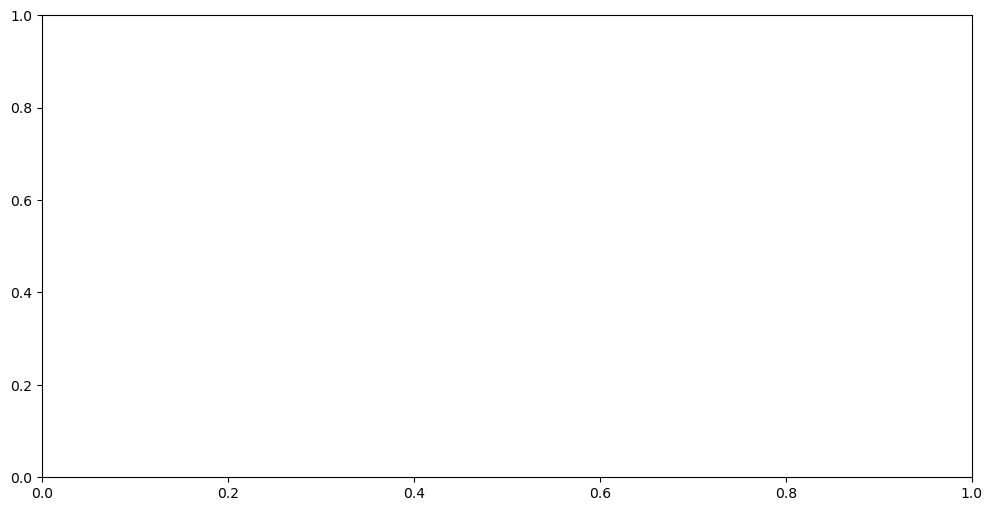

In [36]:
# Create convergence plot

# Restructure data into epochs
chunk_size = 250 #ms
ts = data['ts']
weights = data['pfpc_weights']

weights_p_chunk = weights[::int(chunk_size)]
ts_chunks = ts[::int(chunk_size)]
n_chunks = weights_p_chunk.shape[0]

init_weights = weights_p_chunk[0]
delta_weights_abs = np.diff(weights_p_chunk, axis=0)
delta_weights_rel = delta_weights_abs / init_weights

delta_m_weights = np.abs(np.diff(np.mean(weights_p_chunk, axis=1), axis=0))
delta_var_weights = np.abs(np.diff(np.var(weights_p_chunk, axis=1), axis=0))
all_rows = []

for epoch_idx in range(delta_weights_abs.shape[0]):
    for weight_idx in range(delta_weights_abs.shape[1]):
        all_rows.append({
            'epoch': (epoch_idx + 1)*chunk_size,
            'weight_index': weight_idx,
            'abs_delta': delta_weights_abs[epoch_idx, weight_idx],
            'rel_delta': delta_weights_rel[epoch_idx, weight_idx],
            'mean_delta': delta_m_weights[epoch_idx],
            'var_delta': delta_var_weights[epoch_idx],
            'time_ms': ts_chunks[epoch_idx + 1],
        })

df = pd.DataFrame(all_rows)
max_time = 1000  # ms

order = sorted(df_1000['epoch'].unique())

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# sns.boxplot(
#     x='epoch',
#     y='mean_delta',
#     data=df,
#     ax=axes[0],
#     color='lightsteelblue',
#     whis=[0, 100],
#     showfliers=False,
# )
# sns.stripplot(
#     x='epoch',
#     y='abs_delta',
#     data=df,
#     ax=axes[0],
#     color='navy',
#     alpha=0.6,
#     size=3,
#     jitter=True,
# )
# axes[0].set_title(f'Absolute weight changes per epoch')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Absolute Δ weight')

# epoch_order = sorted(df['epoch'].unique())
# for _, weight_group in df.groupby('weight_index'):
#     weight_data = weight_group.sort_values('epoch')
#     axes[1].plot(
#         epoch_order,
#         weight_data['abs_delta'],
#         color='gray',
#         alpha=0.15,
#         linewidth=1,
#     )

# median_by_epoch = df.groupby('epoch')['abs_delta'].median().reindex(epoch_order)
# axes[1].plot(epoch_order, median_by_epoch, color='black', linewidth=2, label='Median trend')
# axes[1].set_title(f'Weight trendlines across epochs')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Absolute Δ weight')
# axes[1].legend()

# plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='epoch',
    y='mean_delta',
    data=df,
    ax=ax,
    color='lightcoral',
    whis=[0, 100],
    showfliers=False,
)
sns.stripplot(
    x='epoch',
    y='mean_delta',
    data=df,
    ax=ax,
    color='darkred',
    alpha=0.4,
    size=3,
    jitter=True,
)
ax.set_title('Absolute change in meanweight across all epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Absolute Δ mean weight')
plt.xticks(rotation=15)
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    x='epoch',
    y='var_delta',
    data=df,
    ax=ax,
    color='lightcoral',
    whis=[0, 100],
    showfliers=False,
)
sns.stripplot(
    x='epoch',
    y='var_delta',
    data=df,
    ax=ax,
    color='darkred',
    alpha=0.4,
    size=3,
    jitter=True,
)
ax.set_title('Absolute change in variance of weights across all epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Absolute Δ variance of weights')
plt.xticks(rotation=15)
plt.show()

# Plot convergence toward a stable mean within the first 200 ms
window = 500  # ms

ts = data["ts"]
weights = data["pfpc_weights"]

mask = ts <= window
if np.sum(mask) == 0:
    print(f"No time points <= {window} ms in this run.")
else:
    ts_short = ts[mask]
    weights_short = weights[mask]

    # Interpolate all individual weight trajectories to a common 1-ms grid
    time_grid = np.arange(0, window + 1, 1)
    interpolated = []
    for weight_idx in range(weights_short.shape[1]):
        w_traj = weights_short[:, weight_idx]
        interp = np.interp(time_grid, ts_short, w_traj)
        interpolated.append(interp)

    interpolated = np.vstack(interpolated)
    combined_means = interpolated.mean(axis=0)
    combined_std = interpolated.std(axis=0)

    plt.figure(figsize=(12, 6))
    plt.fill_between(
        time_grid,
        combined_means - combined_std,
        combined_means + combined_std,
        color="gray",
        alpha=0.2,
        label="±1 SD (test run)",
    )
    plt.plot(
        time_grid,
        combined_means,
        color="black",
        linewidth=2.5,
        label="Combined mean",
    )
    plt.title(f"Convergence of mean PF-PC weights during first {window} ms (test run)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Mean PF-PC weight")
    plt.xlim(0, window)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [24]:
# Test run_test() function
statepath = Path(r"C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\states\states_nostim__state_saving_test\nostim_isi120.0_isi_std0.0_seed77_simdur3000.0_state.bp")

argv = [
    "--seed", "66",
    "--run-type", "test",
    "--experiment", "nostim",
    "--simdur", "10_000",
    "--monitor-preset", "plasticity_min",
    "--parent-dir", "/home/izet/Olivocerebellar-circuit",
    "--PFPC_plasticity-on", "True",
    "--pretraining-path", str(statepath),
    "--tag", "state_loading_test"
]

args = parse_args(argv)
config = build_test_config(args)

net, data = run_test(config)

Loading checkpoint from C:\Users\HP\ModellingProjects\Olivocerebellar-circuit\states\states_nostim__state_saving_test\nostim_isi120.0_isi_std0.0_seed77_simdur3000.0_state.bp
State loading time taken = 0.6086912155151367 s
Test simulation time taken = 13.779650688171387 s
Saved test runner data to \home\izet\Olivocerebellar-circuit\results\stim_experiments_test_nostim_mon_plasticity_min__state_loading_test\nostim_isi120.0_isi_std0.0_seed77_simdur3000.0\test_nostim_nostim_isi120.0_isi_std0.0_seed77_simdur3000.0_seed66_simdur10000.0.npz
Test saving time taken: 0.02498483657836914 s


In [ ]:
# Check output and dataset, do I want a combined dataset? Eventually yes but during runs for space.

max(data["ts"])


np.float64(9999.0)

In [3]:


import brainpy as bp
import brainpy.helpers as helpers
import inspect

# print("bp.load_state:", bp.load_state)
# print("helpers.load_state:", helpers.load_state)

# print("\nSource of bp.load_state:")
# print(inspect.getsource(bp.load_state))

print("\nSource of bc.load_pytree")
print(inspect.getsource(bc.load_pytree))

print("\nSee if load_state_dict exists")


Source of bc.load_pytree
def load_pytree(
    filename: str,
    target: Optional[Any] = None,
    parallel: bool = True,
) -> PyTree:
    """Load the checkpoint from the given checkpoint path.

    Parameters::

    filename: str
      checkpoint file or directory of checkpoints to restore from.
    parallel: bool
      whether to load seekable checkpoints in parallel, for speed.

    Returns::

    out: Any
      Restored `target` updated from checkpoint file, or if no step specified and
      no checkpoint files present, returns the passed-in `target` unchanged.
      If a file path is specified and is not found, the passed-in `target` will be
      returned. This is to match the behavior of the case where a directory path
      is specified but the directory has not yet been created.
    """
    return braintools.file.msgpack_load(filename, target=target, parallel=parallel)


See if load_state_dict exists


- Breaking up runs into smaller runs with saving state in between
- Coupling saving and loading state effectively
- Test saving and loading state
- Write / change run_test


In [ ]:
# Test monitor preset setup

# Example: train run with specific options
argv = [
    "--seed", "0",
    "--run-type", "baseline",
    "--experiment", "nostim",
    "--simdur", "30_000",
    "--monitor-preset", "plasticity_min",
    "--parent-dir", "/home/izet/Olivocerebellar-circuit",
    "--tag", "monitor_test"
]

args = parse_args(argv)
config = build_baseline_config(args)

# Now call your simulation using the config
net, data = run_baseline(config)  # or simulate(config)

print(data.keys())

Baseline simulation time taken = 61.943278551101685 s
Saved baseline runner data to \home\izet\Olivocerebellar-circuit\results\stim_experiments_baseline_nostim_mon_plasticity_min__monitor_test\baseline_nostim_seed0_simdur30000.0.npz
Baseline saving time taken: 0.12005424499511719 s
dict_keys(['pfpc_weights', 'ts', 'PFPC_plasticity_on', 'OU_stim_pf_on', 'OU_stim_io_on', 'OU_stim_isi_mean', 'OU_stim_freq', 'OU_stim_start', 'OU_stim_amp_io_mean', 'OU_stim_amp_pf_mean', 'OU_stim_dur_io_mean', 'OU_stim_dur_pf_mean', 'monitor_preset', 'seed', 'dt', 'downsample', 'simdur', 'epoch_time', 'pf_pc_pre', 'pf_pc_post', 'io_pc_pre', 'io_pc_post'])


In [22]:
# Test for saving and loading states
argv = [
    "--seed", "75",
    "--run-type", "train",
    "--experiment", "nostim",
    "--simdur", "10_000",
    "--PFPC_plasticity-on", "True",
    "--monitor-preset", "plasticity_min",
    "--tag", "state_saving_test"
]

args = parse_args(argv)
config = build_train_config(args)


# Now call your simulation using the config
net, data, statepath = run_train(config)  

# # Pick a key you care about, e.g. PurkinjeCell t_last_spike
# vars_first_net = net.vars()
# pc_key = [k for k in vars_first_net.keys()
#           if "PurkinjeCell" in k and "V" in k][0]

# print("Using key:", pc_key)

# before_arr = vars_first_net[pc_key].value
# print(f"First network {pc_key}, first 15:", before_arr[:15])

print(str(statepath))


TypeError: super(type, obj): obj must be an instance or subtype of type

In [20]:
argv = [
    "--seed", "66",
    "--run-type", "test",
    "--experiment", "nostim",
    "--simdur", "10_000",
    "--monitor-preset", "plasticity_min",
    "--parent-dir", "/home/izet/Olivocerebellar-circuit",
    "--PFPC_plasticity-on", "False",
    "--pretraining-path", str(statepath),
    "--tag", "state_loading_test"
]

args = parse_args(argv)
config = build_test_config(args)



new_net, new_runner = init_net_and_runner(config['net_params'], seed= config['run_params']['seed'])

print(new_net.vars().keys())
vars = new_net.vars()
print(vars['PFtoPC_BCM3.plasticity_on'].value)

# # 1. Inspect the top-level keys in the saved state
# if isinstance(state, dict):
#     print("Pretraining node names:", list(state.keys()))
# else:
#     # If it's some other mapping-like structure, inspect accordingly
#     try:
#         print("Dir of state:", dir(state))
#     except Exception as e:
#         print("Could not inspect state:", e)

# # 2. Inspect names of nodes in the new network
# nodes = new_net.nodes().subset(bp.DynamicalSystem)
# print("New network node names:", list(nodes.keys()))

# # Pick a key you care about, e.g. PurkinjeCell t_last_spike
# vars_before = new_net.vars()
# pc_key = [k for k in vars_before.keys()
#           if "PurkinjeCell" in k and "V" in k][0]

# print("Using key:", pc_key)

# before_arr = vars_before[pc_key].value
# print("Before load_state, first 10:", before_arr[:10])

state = bc.load_pytree(config["pretraining_state_path"])
result = bp.load_state(new_net, state)  

# # 3. Inspect the names of nodes after loading the state

# print("missing_keys:", result.missing_keys)
# print("unexpected_keys:", result.unexpected_keys)
# nodes_loaded_state = new_net.nodes().subset(bp.DynamicalSystem)
# print("Network node names after reinstate:", list(nodes_loaded_state.keys()))


# # Call your patched load_state
# result = bp.load_state(new_net, state)
# print("StateLoadResult:", result)
# print("missing_keys:", result.missing_keys)
# print("unexpected_keys:", result.unexpected_keys)

# vars_after = new_net.vars()
# after_arr = vars_after[pc_key].value
# print("After load_state, first 10:", after_arr[:10])

for name, value in new_net.vars().items():
    if hasattr(value, "value"):
        arr = np.asarray(value.value)
        if arr.dtype.kind in "fc" and not np.isfinite(arr).all():
            print("non-finite after load:", name, arr)



NameError: name 'statepath' is not defined

In [9]:
# Test for running the test simulation with the loaded state
current_net_params = config['net_params']
run_params = config['run_params']
downsample = run_params['downsample']
duration = 1000
net, runner, data = run_simulation(new_net, new_runner, duration, downsample)

print(net.vars().keys())
vars = net.vars()
print(vars['PurkinjeCell3.V'].value)

dict_keys(['PFBundles3.I_OU', 'PFBundles3.rho', 'PFBundles3.I_stim', 'PurkinjeCell3.V', 'PurkinjeCell3.w', 'PurkinjeCell3.input', 'PurkinjeCell3.dbg_leak', 'PurkinjeCell3.dbg_exp', 'PurkinjeCell3.dbg_current', 'PurkinjeCell3.dbg_w', 'PurkinjeCell3.dbg_delta_w', 'PurkinjeCell3.spike', 'PurkinjeCell3.t_last_spike', 'PurkinjeCell3.cspk', 'PurkinjeCell3.rho', 'DeepCerebellarNuclei3.V', 'DeepCerebellarNuclei3.w', 'DeepCerebellarNuclei3.input', 'DeepCerebellarNuclei3.I_PC', 'DeepCerebellarNuclei3.spike', 'DeepCerebellarNuclei3.t_last_spike', 'PFtoPC_BCM3.plasticity_on', 'PFtoPC_BCM3.weights_per_conn', 'PFtoPC_BCM3.w_cspk', 'PFtoPC_BCM3.w_BCM', 'PFtoPC_BCM3.theta_M', 'PFtoPC_BCM3.dw_cspk', 'PFtoPC_BCM3.dw_BCM', 'CNToIO3.I_cn', 'IOToPC3.last_w_increment', 'HalfWaveStimIOPF3.stim_io_on', 'HalfWaveStimIOPF3.stim_pf_on', 'HalfWaveStimIOPF3.isi_mean', 'HalfWaveStimIOPF3.isi_std', 'HalfWaveStimIOPF3.current_isi', 'HalfWaveStimIOPF3.t_stim_next', 'HalfWaveStimIOPF3.stim_pf_start', 'HalfWaveStimIOPF3

In [19]:
# Test run_test() function
argv = [
    "--seed", "66",
    "--run-type", "test",
    "--experiment", "nostim",
    "--simdur", "10_000",
    "--monitor-preset", "plasticity_min",
    "--parent-dir", "/home/izet/Olivocerebellar-circuit",
    "--pretraining-path", str(statepath),
    "--tag", "state_loading_test"
]

args = parse_args(argv)
config = build_test_config(args)

net, data = run_test(config)


NameError: name 'statepath' is not defined

In [25]:
# Plot weights over time
max_time = np.max(data['ts'])
print(max_time)
figure_2DEF(seed = run_params['seed'], mon= data,  save= True, save_dir = config['figures_dir'],   threshold = 2, xrange = [0.001, max_time-1])

9999.0


KeyError: 'pc.cspk'

In [67]:
# Test for stimuli verify at each stage

argv = [
     "--seed", "66",
        "--run-type", "baseline",
        "--experiment", "fixed-isi",
        "--simdur", "3_000",
        "--PFPC_plasticity-on", "True" ,
        "--OU-stim-io-on", "True" ,
        "--OU-stim-pf-on", "False" ,



        "--OU-stim-isi-mean", "120.0",
        "--monitor-preset", "stimulus_testing",
        "--parent-dir", parent_dir,
        "--OU-stim-isi-mean", "130.0" ,
        "--OU-stim-isi-std", "0.0",
        "--OU-stim-amp-pf-mean", "0.9",
        "--OU-stim-dur-pf-mean", "50.0"
]
args = parse_args(argv)
config = build_baseline_config(args)

net, data = run_baseline(config)


Baseline simulation time taken = 6.012969255447388 s
Saved baseline runner data to \home\izet\Olivocerebellar-circuit\results\stim_experiments_baseline_fixed-isi_mon_stimulus_testing_\baseline_fixed-isi_seed66_simdur3000.0.npz
Baseline saving time taken: 0.016570091247558594 s


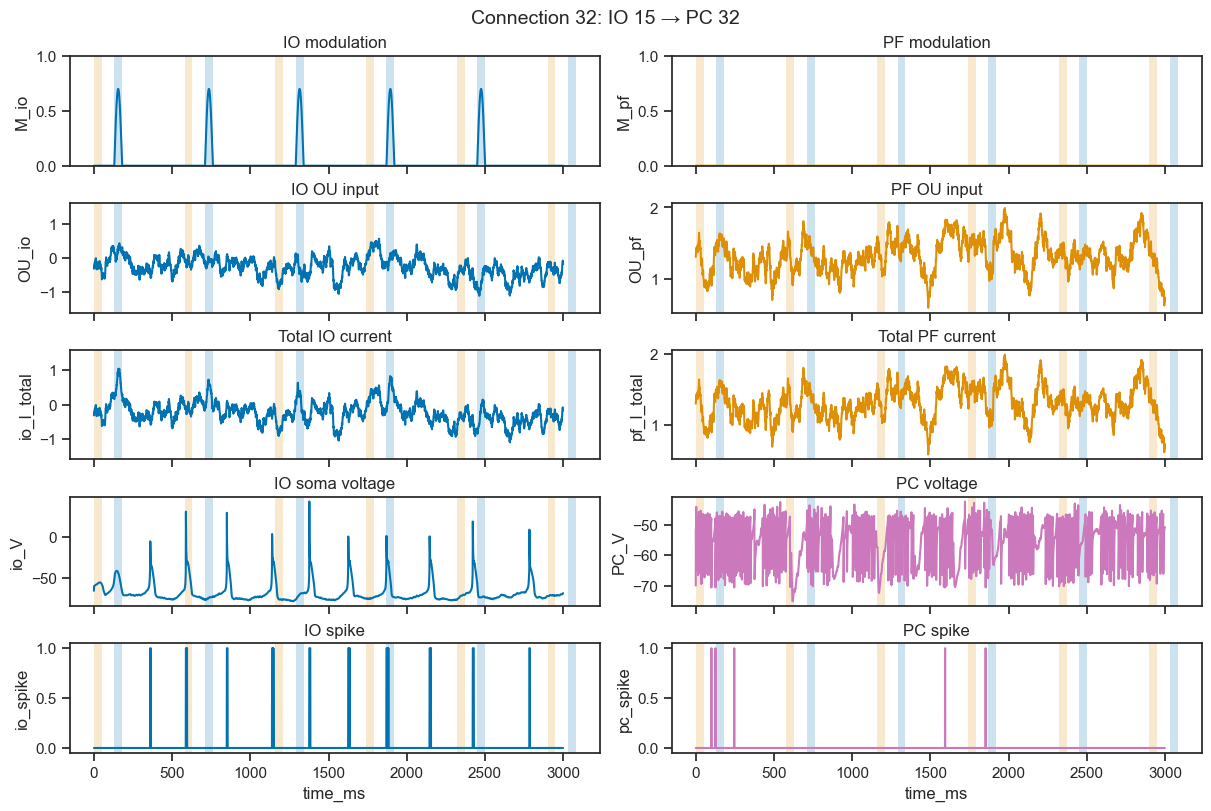

In [ ]:
# Check for stimulus strength: is accumulation bug gone?
# datapaths = [job["run_path"] for job in base_repl_jobs]
# combined_df = pd.DataFrame()
# for dataset in datapaths:
#  with np.load(dataset, allow_pickle=True) as npz:
        # data = {k: npz[k] for k in npz.files}

#       run_df = pd.DataFrame([{
#         "run_id": run_id,
#         "run_path": str(dataset_path),
#         "filename": Path(dataset_path).name,
#         "n_pf_pc_connections": len(data["pf_pc_pre"]),
#         "n_io_pc_connections": len(data["io_pc_pre"]),
#     }])

#     all_run_dfs.append(run_df)



def add_stimulus_bars(ax, io_onsets, pf_onsets,
                      io_duration, pf_duration,
                      io_color, pf_color):
    """
    Add full-height, opaque vertical stimulus bars.

    The plotted traces remain visible because the bars are drawn below
    the default lineplot z-order.
    """
    for onset in io_onsets:
        ax.axvspan(
            onset,
            onset + io_duration,
            ymin=0.0,
            ymax=1.0,
            color=io_color,
            alpha=0.2,
            linewidth=0,
            zorder=1,  # seaborn/matplotlib lines are normally zorder=2
        )

    for onset in pf_onsets:
        ax.axvspan(
            onset,
            onset + pf_duration,
            ymin=0.0,
            ymax=1.0,
            color=pf_color,
            alpha=0.2,
            linewidth=0,
            zorder=1,
        )


argv = [
     "--seed", "66",
        "--run-type", "baseline",
        "--experiment", "fixed-isi",
        "--simdur", "3_000",
        "--PFPC_plasticity-on", "True" ,
        "--OU-stim-io-on", "True" ,
        "--OU-stim-pf-on", "False" ,
        "--OU-stim-isi-mean", "120.0",
        "--monitor-preset", "stimulus_testing",
        "--parent-dir", parent_dir,
        "--OU-stim-isi-mean", "130.0" ,
        "--OU-stim-isi-std", "0.0",
        "--OU-stim-amp-pf-mean", "0.9",
        "--OU-stim-dur-pf-mean", "50.0"
]
args = parse_args(argv)
config = build_baseline_config(args)

net, data = run_baseline(config)


n_timepoints = len(data['ts'])
n_connections = len(data["io_pc_pre"])
df_io_pc_stimcheck = pd.DataFrame({
   'connection_id': np.tile(np.arange(n_connections), n_timepoints),
   'time_ms': np.repeat(data['ts'], n_connections),


   # IO variables
   'stim_io_start': np.repeat(data['stim_io_start'], n_connections),
    'OU_io': (data['io.I_OU'][:,data["io_pc_pre"]]).ravel(),
    'M_io': (data['M_io'][:, data['io_pc_pre']]).ravel(),
    'io_I_total': (data['io.I_total'][:, data['io_pc_pre']]).ravel(),
    'io_V': (data['io.V_soma'][:, data['io_pc_pre']]).ravel(),
    'io_spike': (data['io.spike'][:, data['io_pc_pre']]).ravel(),

   # PC variables
   'PC_V': (data['pc.V'][:,data["io_pc_post"][0:100]]).ravel(),
   'pc_spike': (data['pc.spike'][:,data["io_pc_post"][0:100]]).ravel(),

    # PF variabels: Each PC receives input from all PF nodes, so randomly choosing one PF
    'stim_pf_start': np.repeat(data['stim_pf_start'], n_connections),
    'M_pf': np.repeat(data['M_pf'][:,1], n_connections),
    'OU_pf': np.repeat(data['pf.I_OU'][:,1], n_connections),
    'pf_I_total': np.repeat(data['pf.I_total'][:,1], n_connections),
    'pf_rho': np.repeat(data['pf.I_total'][:,1], n_connections),

})


io_stim_onsets = get_stim_onsets(data["stim_io_start"], data["ts"])
pf_stim_onsets = get_stim_onsets(data["stim_pf_start"], data["ts"])

# Plot 1 connection
connection_id = 32

df_one_connection = df_io_pc_stimcheck.loc[
    df_io_pc_stimcheck["connection_id"] == connection_id
].copy()

sns.set_theme(style="ticks")
colorblind = sns.color_palette("colorblind")
io_stim_duration_ms = 50    # duration of each IO stimulus bar
pf_stim_duration_ms = 50    # duration of each PF stimulus bar

io_color = colorblind[0]
pf_color = colorblind[1]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 8), constrained_layout=True, sharex= True)


sns.lineplot(x="time_ms", y="M_io", data=df_one_connection, ax=axes[0, 0], color=io_color)
sns.lineplot(x="time_ms", y="M_pf", data=df_one_connection, ax=axes[0, 1], color=pf_color)

sns.lineplot(x="time_ms", y="OU_io", data=df_one_connection, ax=axes[1, 0], color=io_color)
sns.lineplot(x="time_ms", y="OU_pf", data=df_one_connection, ax=axes[1, 1], color=pf_color)

sns.lineplot(x="time_ms", y="io_I_total", data=df_one_connection, ax=axes[2, 0], color=io_color)
sns.lineplot(x="time_ms", y="pf_I_total", data=df_one_connection, ax=axes[2, 1], color=pf_color)

sns.lineplot(x="time_ms", y="io_V", data=df_one_connection, ax=axes[3, 0], color=io_color)
sns.lineplot(x="time_ms", y="PC_V", data=df_one_connection, ax=axes[3, 1], color=colorblind[4])

sns.lineplot(x="time_ms", y="io_spike", data=df_one_connection, ax=axes[4, 0], color=io_color)
sns.lineplot(x="time_ms", y="pc_spike", data=df_one_connection, ax=axes[4, 1], color=colorblind[4])

axes[0, 0].set_title("IO modulation")
axes[0, 0].set_ylim(0,1)


axes[0, 1].set_title("PF modulation")
axes[0, 1].set_ylim(0,1)

axes[1, 0].set_title("IO OU input")
axes[1, 0].set_ylim(-1.6,1.6)

axes[1, 1].set_title("PF OU input")
# axes[1,1].set_ylim(-1.6,1.6)

axes[2, 0].set_title("Total IO current")
axes[2,0].set_ylim(-1.6,1.6)

axes[2, 1].set_title("Total PF current")
# axes[2,1].set_ylim(-1.3,1.3)

axes[3, 0].set_title("IO soma voltage")

axes[3, 1].set_title("PC voltage")

axes[4, 0].set_title("IO spike")

axes[4, 1].set_title("PC spike")

for ax in axes.flat:
    add_stimulus_bars(
        ax=ax,
        io_onsets=np.unique(data["stim_io_start"]),
        pf_onsets=np.unique(data["stim_pf_start"]),
        io_duration=io_stim_duration_ms,
        pf_duration=pf_stim_duration_ms,
        io_color=io_color,
        pf_color=pf_color,
    )

io_id= data["io_pc_pre"][connection_id]
pc_id = data["io_pc_post"][connection_id]
fig.suptitle(
    f"Connection {connection_id}: IO {io_id} → PC {pc_id}",
    fontsize=14,
)

plt.show()

In [ ]:
# Check for inhibition bug on PC.v: plot PC voltage around Pf modulation